## Lab 2 CNN

In [1]:
import numpy as np
import pandas as pd
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor #para poder tratar los datos como data set tabular
from collections import Counter

#descarga
train_data = MNIST(root='./datos', train=True, download=True, transform=ToTensor())
test_data = MNIST(root='./datos', train=False, download=True, transform=ToTensor())

In [2]:
from collections import Counter
import matplotlib.pyplot as plt
from torch.utils.data import random_split

### Exploracion y preparacion de datos 

=== EXPLORACION Y PREPARACION DATASET ===
 - Observaciones en entrenamiento: 60000
 - Observaciones en prueba: 10000
	Total: 70000

Total de clases: 10
	['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

Distribucion clases:
  Digito 0: 5923 imagenes (9.87%, diferencia del 1.28% al balance)
  Digito 1: 6742 imagenes (11.24%, diferencia del 12.37% al balance)
  Digito 2: 5958 imagenes (9.93%, diferencia del 0.70% al balance)
  Digito 3: 6131 imagenes (10.22%, diferencia del 2.18% al balance)
  Digito 4: 5842 imagenes (9.74%, diferencia del 2.63% al balance)
  Digito 5: 5421 imagenes (9.04%, diferencia del 9.65% al balance)
  Digito 6: 5918 imagenes (9.86%, diferencia del 1.37% al balance)
  Digito 7: 6265 imagenes (10.44%, diferencia del 4.42% al balance)
  Digito 8: 5851 imagenes (9.75%, diferencia del 2.48% al balance)
  Digito 9: 5949 imagenes (9.92%, diferencia del 0.85% al balance)


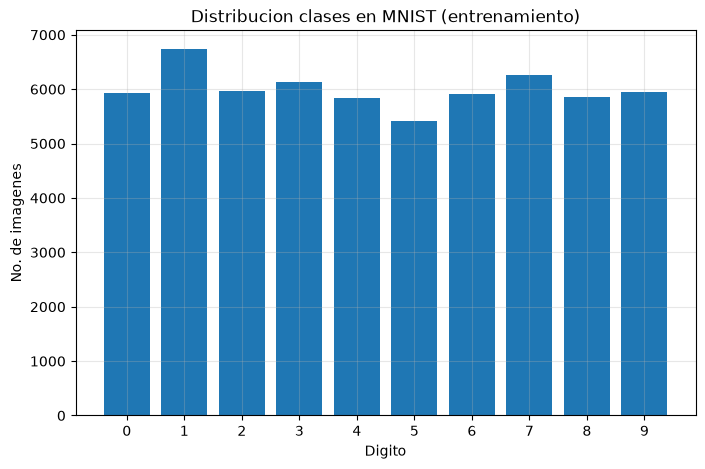

In [3]:
print("=== EXPLORACION Y PREPARACION DATASET ===")
obs_training = len(train_data)
obs_test = len(test_data)
print(f" - Observaciones en entrenamiento: {obs_training}")
print(f" - Observaciones en prueba: {obs_test}")
print(f"\tTotal: {obs_training + obs_test}")
print(f"\nTotal de clases: {len(train_data.classes)}")
print(f"\t{train_data.classes}")
#balanceo clases
train_labels = [label for _, label in train_data]
counter = Counter(train_labels)
total_train = len(train_data)

print(f"\nDistribucion clases:")
for digito in range(10):
    percentage = (counter[digito]/total_train)*100
    expected = total_train/len(train_data.classes)
    diff = abs(counter[digito]- expected)/expected*100

    print(f"  Digito {digito}: {counter[digito]} imagenes ({percentage:.2f}%, diferencia del {diff:.2f}% al balance)")

#grafica
plt.figure(figsize=(8, 5))
plt.bar(counter.keys(), counter.values())
plt.xlabel('Digito')
plt.ylabel('No. de imagenes')
plt.title('Distribucion clases en MNIST (entrenamiento)')
plt.xticks(range(10))
plt.grid(True, alpha=0.3)
plt.show()



--- Dimensiones y valores de pixeles ---
Dimensiones:
 torch.Size([1, 28, 28])
Alto: 28 píxeles
Ancho: 28 píxeles
Rango valores pixeles: 
 - Max: 1.0
 - Min: 0.0
 - Media: 0.1376800686120987
 - Desv. Estandar: 0.3125477433204651
Total pixeles: 784

--- Ejemplos imagenes ---
  Ej. digito 0: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 1: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 2: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 3: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 4: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 5: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 6: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 7: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 8: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000
  Ej. digito 9: shape=torch.Size([1, 28, 28]), min=0.000, max=1.000


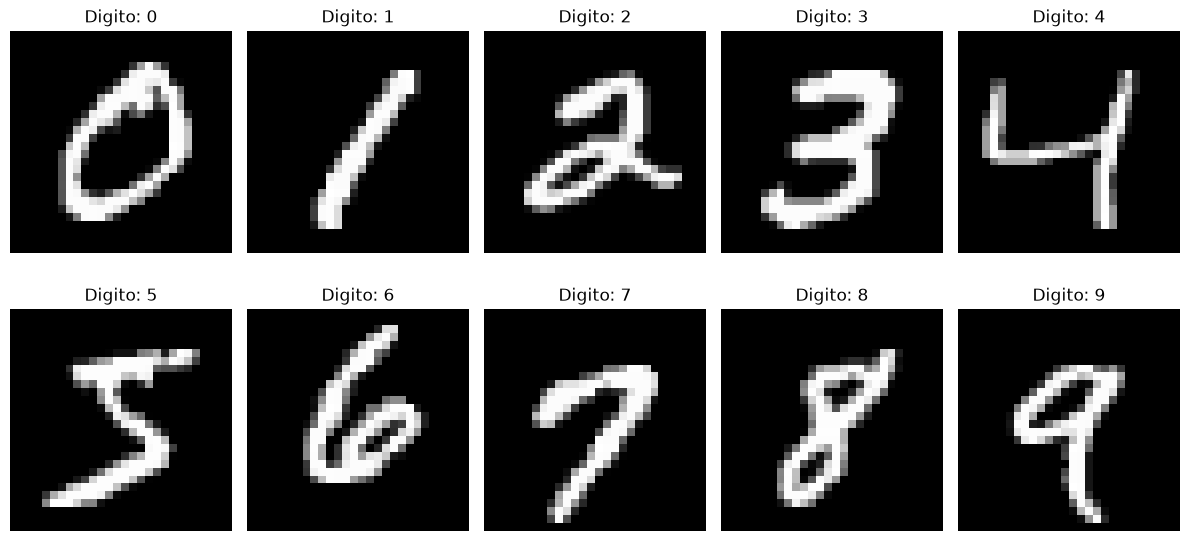

In [4]:
print("--- Dimensiones y valores de pixeles ---")
sample_img, sample_label = train_data[0] #para ejemplo
print(f"Dimensiones:\n {sample_img.shape}")
print(f"Alto: {sample_img.shape[1]} píxeles")
print(f"Ancho: {sample_img.shape[2]} píxeles")
print(f"Rango valores pixeles: \n - Max: {sample_img.max()}\n - Min: {sample_img.min()}\n - Media: {sample_img.mean()}\n - Desv. Estandar: {sample_img.std()}")
print(f"Total pixeles: {sample_img.shape[1] * sample_img.shape[2]}")

#ejmplos imagnes digitos
print("\n--- Ejemplos imagenes ---")
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    for img, label in train_data:
        if label == i:
            ax.imshow(img.squeeze(), cmap='gray')
            ax.set_title(f'Digito: {i}')
            ax.axis('off')
            print(f"  Ej. digito {i}: shape={img.shape}, min={img.min():.3f}, max={img.max():.3f}")
            break
plt.tight_layout()
plt.show()

In [5]:
#division para validacion
train_size = int(0.8*len(train_data))
val_size = len(train_data) - train_size #validacion 20%

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

print("--- Division Final ---")
print(f"Entrenamiento: {len(train_dataset)} imágenes")
print(f"Validación: {len(val_dataset)} imágenes")
print(f"Prueba: {len(test_data)} imágenes")

--- Division Final ---
Entrenamiento: 48000 imágenes
Validación: 12000 imágenes
Prueba: 10000 imágenes


### Construcción y entrenamiento de las arquitecturas 

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_layers=[256, 128], activation='relu', dropout=0.0):
        super(MLP, self).__init__()

        layers = []
        prev_dim = input_dim

        #capas ocultas
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))

            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.1))
            elif activation == 'selu':
                layers.append(nn.SELU())

            if dropout > 0:
                            layers.append(nn.Dropout(dropout))
            
            prev_dim = hidden_dim

        #capa salida/regresion
        layers.append(nn.Linear(prev_dim, 10))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        #aplanar
        x = x.view(x.size(0), -1)
        return self.model(x)

#CNN
class CNN(nn.Module):
    def __init__(self, num_classes=10, dropout_conv=0.0, dropout_fc=0.5):
        super(CNN, self).__init__()

        #bloque convulcional1 y 2
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32,64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc = nn.Sequential(
            nn.Dropout(dropout_fc),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout_conv),
            nn.Linear(256, num_classes)
        ) #fully conn capas

    def forward(self, x):
        x = self.conv1(x)
        x= self.conv2(x)
        x=self.conv3(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
                        

In [9]:
#entrenamiento y eval
def training_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()*images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    average_loss = total_loss/len(train_loader.dataset)
    acc = 100*correct/total
    return average_loss, acc

def evaluate(model, data_loader, criterion, device): #evalcion modleo
    model.eval()
    total_loss = 0
    all_preds =[]
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(data_loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels
    }

def training_model(model, train_loader, val_loader, optimizer, criterion, epochs, device, verbose=True):
    train_losses = []
    val_losses = []
    train_accs=[]
    val_accs = []

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc = training_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_metrics['loss'])
        train_accs.append(train_acc)
        val_accs.append(val_metrics['accuracy'])

        #mejor modleo
        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            best_model_state = model.state_dict().copy()

        if verbose and (epoch+1)%5 == 0:
            print(f" Epoch {epoch+1}/{epochs}:\n\t-Perdida train: {train_loss:.2f}\n\t-Accuracy train: {train_acc:.2f}%\n\t-Perdida validacion: {val_metrics['loss']:.2f}\n\t-Accuracy validacion: {val_metrics['accuracy']:.2f}%")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc
    }

In [10]:
#hiperparametros
print("\n--- Hiperparametros MLP ---")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
mlp_configs = [
    #base
    {
        'name': 'MLP Base',
        'hidden_layers': [128, 64],
        'activation': 'relu',
        'dropout': 0.0,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    #variacioens de arquitectura
    {
        'name': 'MLP Arquitectura 1',
        'hidden_layers': [256, 128, 64],
        'activation': 'relu',
        'dropout': 0.0,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    {
        'name': 'MLP Arquitectura 2',
        'hidden_layers': [512, 256, 128],
        'activation': 'relu',
        'dropout': 0.0,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    #variacion de acitvacion
    {
        'name': 'MLP LeakyReLU',
        'hidden_layers': [128, 64],
        'activation': 'leaky_relu',
        'dropout': 0.0,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    #varicon dropout
    {
        'name': 'MLP Dropout 0.2',
        'hidden_layers': [128, 64],
        'activation': 'relu',
        'dropout': 0.2,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    {
        'name': 'MLP Dropout 0.5',
        'hidden_layers': [128, 64],
        'activation': 'relu',
        'dropout': 0.5,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    #variacion lr
    {
        'name': 'MLP lr 0.0005',
        'hidden_layers': [128, 64],
        'activation': 'relu',
        'dropout': 0.0,
        'learning_rate': 0.0005,
        'batch_size': 64,
        'epochs': 20
    },
    {
        'name': 'MLP lr 0.01',
        'hidden_layers': [128, 64],
        'activation': 'relu',
        'dropout': 0.0,
        'learning_rate': 0.01,
        'batch_size': 64,
        'epochs': 20
    },
    #mejores
    {
        'name': 'Mejor MLP',
        'hidden_layers': [256, 128, 64],
        'activation': 'leaky_relu',
        'dropout': 0.2,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    }
]

mlp_results = []
criterion = nn.CrossEntropyLoss()

for config in mlp_configs:
    print(f"\n--- {config['name']} ---")
    print(f"Config: {config}")

    #dataloaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

    model = MLP(
        input_dim=784,
        hidden_layers=config['hidden_layers'],
        activation=config['activation'],
        dropout=config['dropout']
    ).to(device)
    
    #conteo params
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parametros: {n_params:,}")


    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    
    history = training_model(
        model, train_loader, val_loader, 
        optimizer, criterion, 
        config['epochs'], device, verbose=True
    )
    
    val_metrics = evaluate(model, val_loader, criterion, device)
    
    result = {
        'name': config['name'],
        'config': config,
        'n_params': n_params,
        'history': history,
        'val_metrics': val_metrics
    }
    mlp_results.append(result)
    
    print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val F1: {val_metrics['f1']:.4f}")


print("\n--- Hiperparametros CNN ---")

cnn_configs = [
    #base
    {
        'name': 'CNN Base',
        'dropout_conv': 0.0,
        'dropout_fc': 0.5,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    #variacion dropout convoluciones
    {
        'name': 'CNN Dropout Conv 0.1',
        'dropout_conv': 0.1,
        'dropout_fc': 0.5,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    {
        'name': 'CNN Dropout Conv 0.3',
        'dropout_conv': 0.3,
        'dropout_fc': 0.5,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    #variacion dorput fully connected
    {
        'name': 'CNN Dropout FC 0.3',
        'dropout_conv': 0.0,
        'dropout_fc': 0.3,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    {
        'name': 'CNN Dropout FC 0.7',
        'dropout_conv': 0.0,
        'dropout_fc': 0.7,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    },
    #varaicion lr
    {
        'name': 'CNN LR 0.0005',
        'dropout_conv': 0.0,
        'dropout_fc': 0.5,
        'learning_rate': 0.0005,
        'batch_size': 64,
        'epochs': 20
    },
    {
        'name': 'CNN LR 0.01',
        'dropout_conv': 0.0,
        'dropout_fc': 0.5,
        'learning_rate': 0.01,
        'batch_size': 64,
        'epochs': 20
    },
    #mejor comb
    {
        'name': 'CNN Mejor',
        'dropout_conv': 0.2,
        'dropout_fc': 0.5,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 20
    }
]

cnn_results = []

for config in cnn_configs:
    print(f"\n--- {config['name']} ---")
    print(f"Config: {config}")
    
    #dataLoaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    model = CNN(
        num_classes=10,
        dropout_conv=config['dropout_conv'],
        dropout_fc=config['dropout_fc']
    ).to(device)
    
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parametros: {n_params:,}")
    
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    
    history = training_model(
        model, train_loader, val_loader, 
        optimizer, criterion, 
        config['epochs'], device, verbose=True
    )
    
    val_metrics = evaluate(model, val_loader, criterion, device)
    
    result = {
        'name': config['name'],
        'config': config,
        'n_params': n_params,
        'history': history,
        'val_metrics': val_metrics
    }
    cnn_results.append(result)
    
    print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val F1: {val_metrics['f1']:.4f}")


--- Hiperparametros MLP ---
Dispositivo: cpu

--- MLP Base ---
Config: {'name': 'MLP Base', 'hidden_layers': [128, 64], 'activation': 'relu', 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20}
Parametros: 109,770
 Epoch 5/20:
	-Perdida train: 0.04
	-Accuracy train: 98.59%
	-Perdida validacion: 0.08
	-Accuracy validacion: 0.98%
 Epoch 10/20:
	-Perdida train: 0.02
	-Accuracy train: 99.23%
	-Perdida validacion: 0.08
	-Accuracy validacion: 0.98%
 Epoch 15/20:
	-Perdida train: 0.02
	-Accuracy train: 99.39%
	-Perdida validacion: 0.08
	-Accuracy validacion: 0.98%
 Epoch 20/20:
	-Perdida train: 0.01
	-Accuracy train: 99.63%
	-Perdida validacion: 0.09
	-Accuracy validacion: 0.98%
Val Accuracy: 0.9785
Val F1: 0.9785

--- MLP Arquitectura 1 ---
Config: {'name': 'MLP Arquitectura 1', 'hidden_layers': [256, 128, 64], 'activation': 'relu', 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20}
Parametros: 243,658
 Epoch 5/20:
	-Perdida train: 0.04
	-Accuracy tr

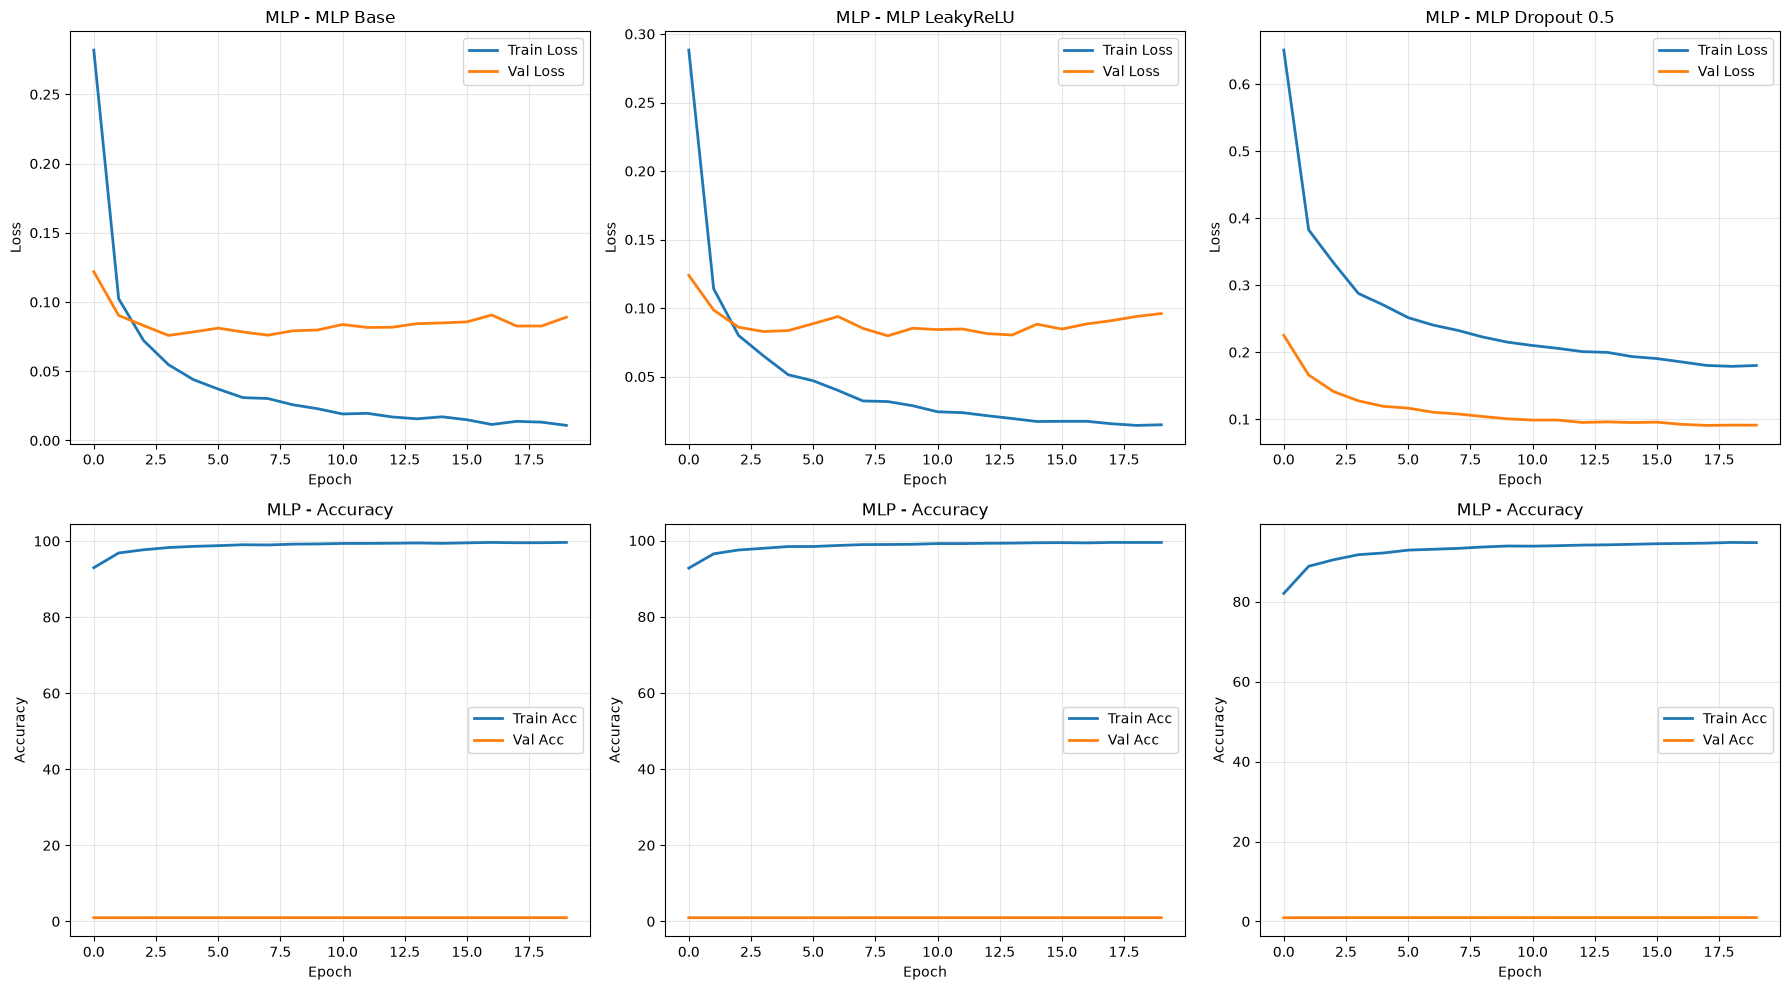

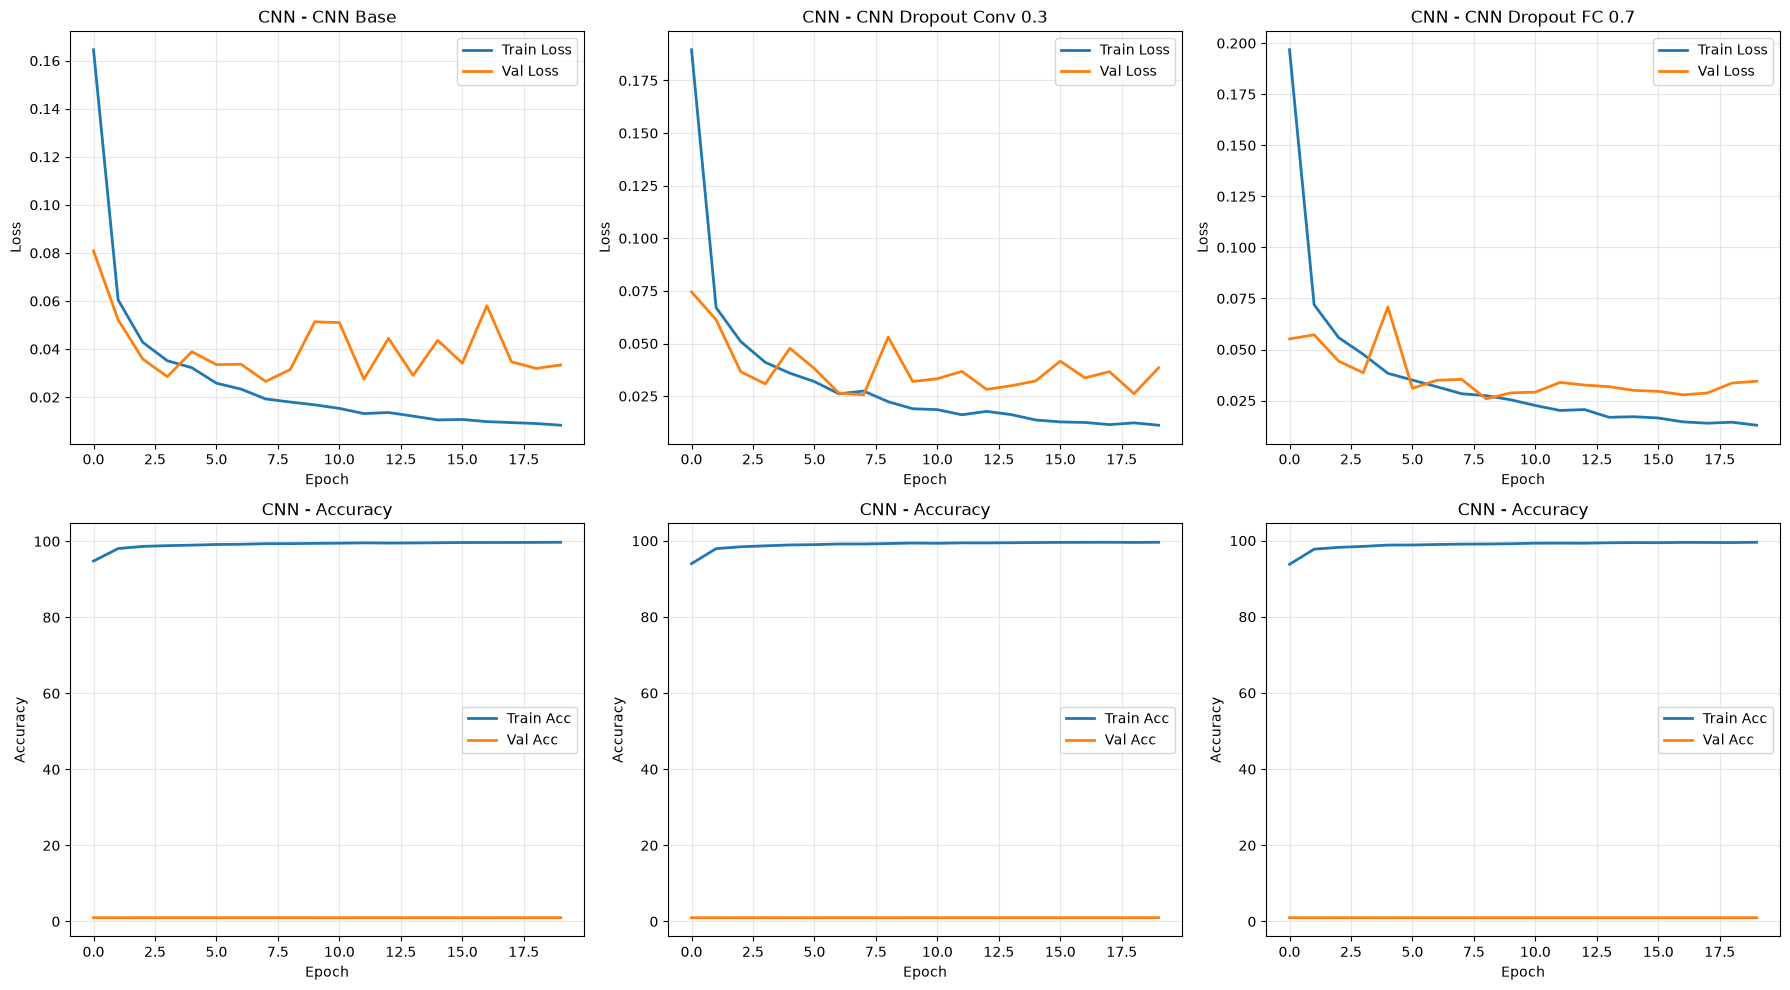

=== COMPARACION RESULTADOS ===

--- MLP ---
Configuracion        | Params       | Val Acc    | Val F1     | Precision    | Recall      
------------------------------------------------------------------------------------------
MLP Base             |    109,770 |    0.9785 |    0.9785 |      0.9785 |      0.9785
MLP Arquitectura 1   |    243,658 |    0.9812 |    0.9813 |      0.9813 |      0.9812
MLP Arquitectura 2   |    569,226 |    0.9818 |    0.9817 |      0.9818 |      0.9818
MLP LeakyReLU        |    109,770 |    0.9770 |    0.9770 |      0.9771 |      0.9770
MLP Dropout 0.2      |    109,770 |    0.9803 |    0.9803 |      0.9804 |      0.9803
MLP Dropout 0.5      |    109,770 |    0.9720 |    0.9720 |      0.9720 |      0.9720
MLP lr 0.0005        |    109,770 |    0.9778 |    0.9778 |      0.9779 |      0.9778
MLP lr 0.01          |    109,770 |    0.9811 |    0.9811 |      0.9811 |      0.9811
Mejor MLP            |    243,658 |    0.9795 |    0.9795 |      0.9796 |      0.9795

In [11]:
#graficas
mlp_plot_indices = [0, 3, 5]  #base, leaky relu, dropout 0.5
cnn_plot_indices = [0, 2, 4]  #base, dropout conv 0.3, dropout fc 0.7

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#graficas mlp
for idx, plot_idx in enumerate(mlp_plot_indices):
    if plot_idx < len(mlp_results):
        result = mlp_results[plot_idx]
        history = result['history']
        
        ax1 = axes[0, idx]
        ax1.plot(history['train_losses'], label='Train Loss', linewidth=2)
        ax1.plot(history['val_losses'], label='Val Loss', linewidth=2)
        ax1.set_title(f'MLP - {result["name"]}')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2 = axes[1, idx]
        ax2.plot(history['train_accs'], label='Train Acc', linewidth=2)
        ax2.plot(history['val_accs'], label='Val Acc', linewidth=2)
        ax2.set_title(f'MLP - Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#graficas cnn
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, plot_idx in enumerate(cnn_plot_indices):
    if plot_idx < len(cnn_results):
        result = cnn_results[plot_idx]
        history = result['history']
        
        ax1 = axes[0, idx]
        ax1.plot(history['train_losses'], label='Train Loss', linewidth=2)
        ax1.plot(history['val_losses'], label='Val Loss', linewidth=2)
        ax1.set_title(f'CNN - {result["name"]}')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2 = axes[1, idx]
        ax2.plot(history['train_accs'], label='Train Acc', linewidth=2)
        ax2.plot(history['val_accs'], label='Val Acc', linewidth=2)
        ax2.set_title(f'CNN - Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("=== COMPARACION RESULTADOS ===")
print("\n--- MLP ---")
print(f"{'Configuracion':<20} | {'Params':<12} | {'Val Acc':<10} | {'Val F1':<10} | {'Precision':<12} | {'Recall':<12}")
print("-"*90)
for r in mlp_results:
    print(f"{r['name']:<20} | {r['n_params']:>10,} | {r['val_metrics']['accuracy']:>9.4f} | {r['val_metrics']['f1']:>9.4f} | {r['val_metrics']['precision']:>11.4f} | {r['val_metrics']['recall']:>11.4f}")

print("\n--- CNN ---")
print(f"{'Configuracion':<20} | {'Params':<12} | {'Val Acc':<10} | {'Val F1':<10} | {'Precision':<12} | {'Recall':<12}")
print("-"*90)
for r in cnn_results:
    print(f"{r['name']:<20} | {r['n_params']:>10,} | {r['val_metrics']['accuracy']:>9.4f} | {r['val_metrics']['f1']:>9.4f} | {r['val_metrics']['precision']:>11.4f} | {r['val_metrics']['recall']:>11.4f}")




In [14]:
import seaborn as sns

=== EVALUACION MEJORES MODELOS (TEST) ===
Mejor MLP: MLP Arquitectura 2 (Val Acc: 0.98)
Mejor CNN: MLP Arquitectura 2 (Val Acc: 0.99)

--- MLP FINAL ---
Test Accuracy: 0.9830
Test Precision: 0.9830
Test Recall: 0.9830
Test F1: 0.9830
--- CNN FINAL ---
Test Accuracy: 0.9925
Test Precision: 0.9925
Test Recall: 0.9925
Test F1: 0.9925


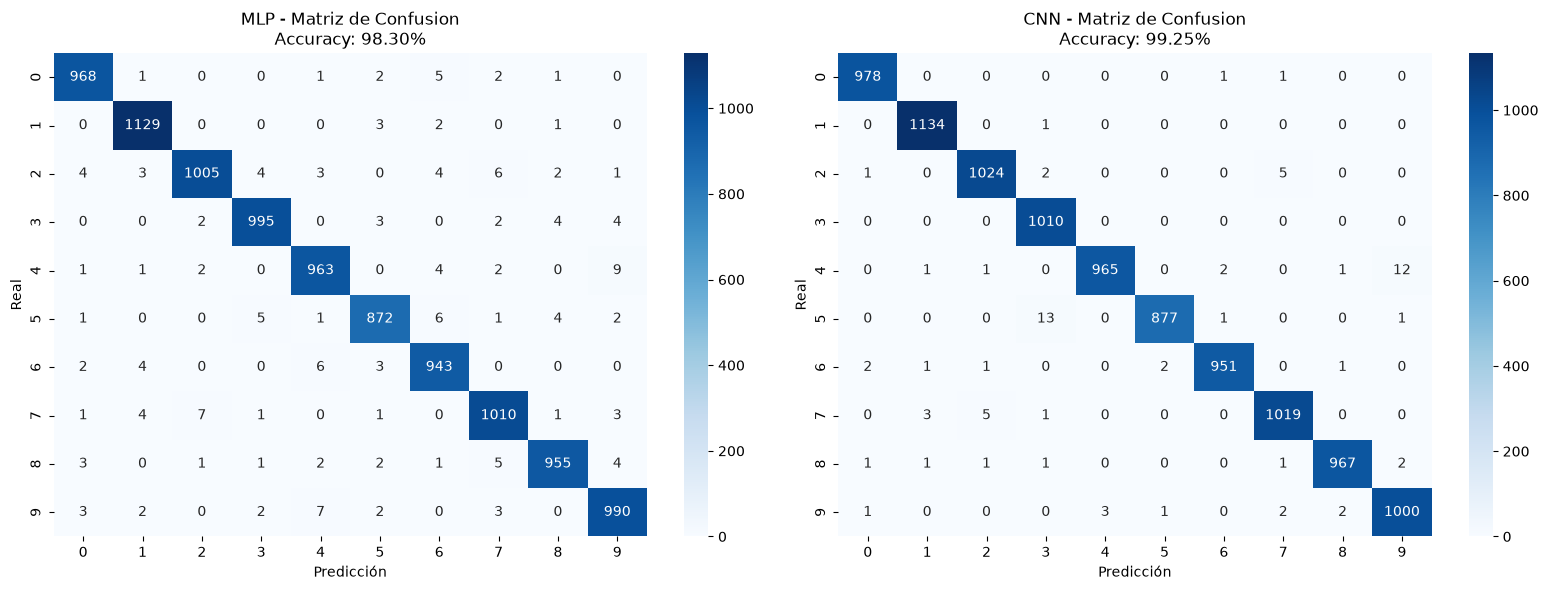

In [15]:
#evalucaicon final
print("=== EVALUACION MEJORES MODELOS (TEST) ===")

best_mlp_config = np.argmax([r['val_metrics']['accuracy'] for r in mlp_results])
best_cnn_config = np.argmax([r['val_metrics']['accuracy'] for r in cnn_results])

best_mlp_result = mlp_results[best_mlp_config]
best_cnn_result = cnn_results[best_cnn_config]


print(f"Mejor MLP: {best_mlp_result['name']} (Val Acc: {best_mlp_result['val_metrics']['accuracy']:.2f})")
print(f"Mejor CNN: {best_mlp_result['name']} (Val Acc: {best_cnn_result['val_metrics']['accuracy']:.2f})")

test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print("\n--- MLP FINAL ---")
mlp_final = best_mlp_result['history']['model']
mlp_test_metrics = evaluate(mlp_final, test_loader, criterion, device)
print(f"Test Accuracy: {mlp_test_metrics['accuracy']:.4f}")
print(f"Test Precision: {mlp_test_metrics['precision']:.4f}")
print(f"Test Recall: {mlp_test_metrics['recall']:.4f}")
print(f"Test F1: {mlp_test_metrics['f1']:.4f}")

print("--- CNN FINAL ---")
cnn_final = best_cnn_result['history']['model']
cnn_test_metrics = evaluate(cnn_final, test_loader, criterion, device)
print(f"Test Accuracy: {cnn_test_metrics['accuracy']:.4f}")
print(f"Test Precision: {cnn_test_metrics['precision']:.4f}")
print(f"Test Recall: {cnn_test_metrics['recall']:.4f}")
print(f"Test F1: {cnn_test_metrics['f1']:.4f}")


#matrices de conf
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#mlp
cm_mlp = confusion_matrix(mlp_test_metrics['labels'], mlp_test_metrics['predictions'])
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'MLP - Matriz de Confusion\nAccuracy: {mlp_test_metrics["accuracy"]:.2%}')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

#cnn
cm_cnn = confusion_matrix(cnn_test_metrics['labels'], cnn_test_metrics['predictions'])
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'CNN - Matriz de Confusion\nAccuracy: {cnn_test_metrics["accuracy"]:.2%}')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()


In [22]:
#underfitting overfitting
print("=== UNDERFITTING Y OVERFITTING ===")
def analyze_training_gap(result, model_name):
    history = result['history']
    train_loss_end = history['train_losses'][-1]
    val_loss_end = history['val_losses'][-1]
    train_acc_end = history['train_accs'][-1]
    val_acc_end = history['val_accs'][-1]
    
    loss_gap = val_loss_end - train_loss_end
    acc_gap = train_acc_end - val_acc_end
    
    print(f"\n{model_name} - {result['name']}:")
    print(f"  Train Loss final: {train_loss_end:.2f}")
    print(f"  Val Loss final: {val_loss_end:.2f}")
    print(f"  Loss Gap: {loss_gap:.2f}")
    print(f"  Train Acc final: {train_acc_end:.2f}%")
    print(f"  Val Acc final: {val_acc_end:.2f}%")
    print(f"  Acc Gap: {acc_gap:.2f}%")
    
    if loss_gap > 0.3 and acc_gap > 5:
        print("  Probablidida de overfitting")
    elif loss_gap < -0.1:
        print("  Probabilidad de underfitting")
    else:
        print("  Balance entre training y validacion")


print(f"\n--- MEJORES MODELOS ---")
analyze_training_gap(best_mlp_result, "MLP")
analyze_training_gap(best_cnn_result, "CNN")


print("\n=== RESUMEN ===")
print(f"\n{'Metrica':<20} | {'MLP':<20} | {'CNN':<20}")
print("-"*60)
print(f"{'Test Accuracy':<20} | {mlp_test_metrics['accuracy']:>19.4f} | {cnn_test_metrics['accuracy']:>19.4f}")
print(f"{'Test Precision':<20} | {mlp_test_metrics['precision']:>19.4f} | {cnn_test_metrics['precision']:>19.4f}")
print(f"{'Test Recall':<20} | {mlp_test_metrics['recall']:>19.4f} | {cnn_test_metrics['recall']:>19.4f}")
print(f"{'Test F1-Score':<20} | {mlp_test_metrics['f1']:>19.4f} | {cnn_test_metrics['f1']:>19.4f}")
print(f"{'Parametros':<20} | {best_mlp_result['n_params']:>19,} | {best_cnn_result['n_params']:>19,}")
print(f"{'Mejor Config':<20} | {best_mlp_result['name']:<19} | {best_cnn_result['name']:<19}")

=== UNDERFITTING Y OVERFITTING ===

--- MEJORES MODELOS ---

MLP - MLP Arquitectura 2:
  Train Loss final: 0.01
  Val Loss final: 0.08
  Loss Gap: 0.07
  Train Acc final: 99.67%
  Val Acc final: 0.98%
  Acc Gap: 98.69%
  Balance entre training y validacion

CNN - CNN Dropout Conv 0.1:
  Train Loss final: 0.01
  Val Loss final: 0.03
  Loss Gap: 0.02
  Train Acc final: 99.71%
  Val Acc final: 0.99%
  Acc Gap: 98.72%
  Balance entre training y validacion

=== RESUMEN ===

Metrica              | MLP                  | CNN                 
------------------------------------------------------------
Test Accuracy        |              0.9830 |              0.9925
Test Precision       |              0.9830 |              0.9925
Test Recall          |              0.9830 |              0.9925
Test F1-Score        |              0.9830 |              0.9925
Parametros           |             569,226 |             620,234
Mejor Config         | MLP Arquitectura 2  | CNN Dropout Conv 0.1
